# 1. Analisi Esplorativa dei Dati

In questo notebook viene analizzato il dataset relativo a partite ranked Diamond di League of Legends osservate nei primi 10 minuti di gioco.

L'obiettivo dell'analisi esplorativa è comprendere la struttura del dataset, verificare la qualità dei dati, studiare la distribuzione della variabile target `blueWins`, individuare eventuali valori anomali e analizzare le relazioni di correlazione e collinearità tra le variabili.

Questa fase precede la costruzione dei modelli di Machine Learning e permette di identificare feature ridondanti o potenzialmente rilevanti per la previsione della squadra vincitrice.

## 1.1 Importazione delle librerie

Vengono importate le librerie necessarie per la manipolazione dei dati, i calcoli numerici e la visualizzazione grafica.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## 1.2 Caricamento del dataset

Il dataset viene caricato tramite Pandas. Il file CSV si trova nella cartella `data`, mentre il notebook si trova nella cartella `notebooks`.

Per questo viene utilizzato il percorso relativo `../data/`.

In [52]:
df = pd.read_csv("../data/high_diamond_ranked_10min.csv")
df.head()


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,blueHeralds,blueTowersDestroyed,blueTotalGold,blueAvgLevel,blueTotalExperience,blueTotalMinionsKilled,blueTotalJungleMinionsKilled,blueGoldDiff,blueExperienceDiff,blueCSPerMin,blueGoldPerMin,redWardsPlaced,redWardsDestroyed,redFirstBlood,redKills,redDeaths,redAssists,redEliteMonsters,redDragons,redHeralds,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,0,0,17210,6.6,17039,195,36,643,-8,19.5,1721.0,15,6,0,6,9,8,0,0,0,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,0,0,14712,6.6,16265,174,43,-2908,-1173,17.4,1471.2,12,1,1,5,5,2,2,1,1,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,0,0,16113,6.4,16221,186,46,-1172,-1033,18.6,1611.3,15,3,1,11,7,14,0,0,0,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,1,0,15157,7.0,17954,201,55,-1321,-7,20.1,1515.7,15,2,1,5,4,10,0,0,0,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,0,0,16400,7.0,18543,210,57,-1004,230,21.0,1640.0,17,2,1,6,6,7,1,1,0,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


## 1.3 Struttura del dataset

Per prima cosa vengono analizzate le dimensioni del dataset e le variabili disponibili.

In [53]:
print("Numero di righe:", df.shape[0])
print("Numero di colonne:", df.shape[1])
print(df.columns.tolist())

Numero di righe: 9879
Numero di colonne: 40
['gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed', 'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists', 'blueEliteMonsters', 'blueDragons', 'blueHeralds', 'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel', 'blueTotalExperience', 'blueTotalMinionsKilled', 'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff', 'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed', 'redFirstBlood', 'redKills', 'redDeaths', 'redAssists', 'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed', 'redTotalGold', 'redAvgLevel', 'redTotalExperience', 'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff', 'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin']


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   int64  
 13  blueAvgLevel  

### Controllo dei valori mancanti

La presenza di valori nulli può creare problemi durante l'addestramento dei modelli di Machine Learning. Viene quindi verificato se il dataset contiene dati mancanti.

In [55]:
null_values = df.isnull().sum()

print(null_values)
print("\nValori nulli totali:", null_values.sum())

gameId                          0
blueWins                        0
blueWardsPlaced                 0
blueWardsDestroyed              0
blueFirstBlood                  0
blueKills                       0
blueDeaths                      0
blueAssists                     0
blueEliteMonsters               0
blueDragons                     0
blueHeralds                     0
blueTowersDestroyed             0
blueTotalGold                   0
blueAvgLevel                    0
blueTotalExperience             0
blueTotalMinionsKilled          0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueCSPerMin                    0
blueGoldPerMin                  0
redWardsPlaced                  0
redWardsDestroyed               0
redFirstBlood                   0
redKills                        0
redDeaths                       0
redAssists                      0
redEliteMonsters                0
redDragons                      0
redHeralds    

### Controllo dei duplicati

Le righe duplicate potrebbero rappresentare partite inserite più volte nel dataset e potrebbero alterare i risultati dell'analisi.

In [56]:
print("Righe duplicate:", df.duplicated().sum())
print("gameId duplicati:", df["gameId"].duplicated().sum())

Righe duplicate: 0
gameId duplicati: 0


### Esclusione di `gameId` dalle analisi statistiche

La colonna `gameId` rappresenta solamente un identificatore univoco della partita e non contiene informazioni utili per prevedere la vittoria.

Per questo motivo viene esclusa dalle analisi statistiche successive.

In [57]:
df_analysis = df.drop(columns=["gameId"])

## 1.4 Statistiche descrittive

Le statistiche descrittive consentono di osservare valori come media, deviazione standard, minimo, massimo, mediana e quartili delle variabili numeriche.

In [58]:
df_analysis.describe().T

,count,mean,std,min,25%,50%,75%,max
blueWins,9879.0,0.499038,0.500024,0.0,0.00,0.0,1.00,1.0
blueWardsPlaced,9879.0,22.288288,18.019177,5.0,14.00,16.0,20.00,250.0
blueWardsDestroyed,9879.0,2.824881,2.174998,0.0,1.00,3.0,4.00,27.0
blueFirstBlood,9879.0,0.504808,0.500002,0.0,0.00,1.0,1.00,1.0
blueKills,9879.0,6.183925,3.011028,0.0,4.00,6.0,8.00,22.0
blueDeaths,9879.0,6.137666,2.933818,0.0,4.00,6.0,8.00,22.0
blueAssists,9879.0,6.645106,4.064520,0.0,4.00,6.0,9.00,29.0
blueEliteMonsters,9879.0,0.549954,0.625527,0.0,0.00,0.0,1.00,2.0
blueDragons,9879.0,0.361980,0.480597,0.0,0.00,0.0,1.00,1.0
blueHeralds,9879.0,0.187974,0.390712,0.0,0.00,0.0,0.00,1.0


### Varianza delle variabili

La varianza misura quanto i valori di una variabile sono dispersi rispetto alla media.

Una varianza elevata indica una maggiore dispersione dei valori.

In [59]:
variance = df_analysis.var()

variance.sort_values(ascending=False)

blueGoldDiff                    6.018922e+06
redGoldDiff                     6.018922e+06
redExperienceDiff               3.687823e+06
blueExperienceDiff              3.687823e+06
blueTotalGold                   2.357596e+06
redTotalGold                    2.222748e+06
blueTotalExperience             1.441257e+06
redTotalExperience              1.436603e+06
blueGoldPerMin                  2.357596e+04
redGoldPerMin                   2.222748e+04
redTotalMinionsKilled           4.801212e+02
blueTotalMinionsKilled          4.777913e+02
redWardsPlaced                  3.406766e+02
blueWardsPlaced                 3.246907e+02
redTotalJungleMinionsKilled     1.005585e+02
blueTotalJungleMinionsKilled    9.797599e+01
blueAssists                     1.652032e+01
redAssists                      1.648857e+01
redDeaths                       9.066289e+00
blueKills                       9.066289e+00
redKills                        8.607286e+00
blueDeaths                      8.607286e+00
redCSPerMi

In [60]:
summary = pd.DataFrame({
    "media": df_analysis.mean(),
    "varianza": df_analysis.var(),
    "deviazione_standard": df_analysis.std(),
    "minimo": df_analysis.min(),
    "mediana": df_analysis.median(),
    "massimo": df_analysis.max()
})

summary

,media,varianza,deviazione_standard,minimo,mediana,massimo
blueWins,0.499038,2.500244e-01,0.500024,0.0,0.0,1.0
blueWardsPlaced,22.288288,3.246907e+02,18.019177,5.0,16.0,250.0
blueWardsDestroyed,2.824881,4.730618e+00,2.174998,0.0,3.0,27.0
blueFirstBlood,0.504808,2.500022e-01,0.500002,0.0,1.0,1.0
blueKills,6.183925,9.066289e+00,3.011028,0.0,6.0,22.0
blueDeaths,6.137666,8.607286e+00,2.933818,0.0,6.0,22.0
blueAssists,6.645106,1.652032e+01,4.064520,0.0,6.0,29.0
blueEliteMonsters,0.549954,3.912834e-01,0.625527,0.0,0.0,2.0
blueDragons,0.361980,2.309738e-01,0.480597,0.0,0.0,1.0
blueHeralds,0.187974,1.526555e-01,0.390712,0.0,0.0,1.0


## 1.5 Analisi della variabile target `blueWins`

La variabile `blueWins` rappresenta il risultato finale della partita:

- `1`: vittoria della squadra Blue;
- `0`: sconfitta della squadra Blue.

È importante controllare il bilanciamento delle classi perché una forte prevalenza di una classe potrebbe rendere l'accuracy una metrica poco significativa.

In [61]:
class_counts = df["blueWins"].value_counts().sort_index()

class_percentages = (
    df["blueWins"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

balance_table = pd.DataFrame({
    "numero_partite": class_counts,
    "percentuale": class_percentages
})

balance_table

,numero_partite,percentuale
blueWins,,
0,4949,50.096164
1,4930,49.903836


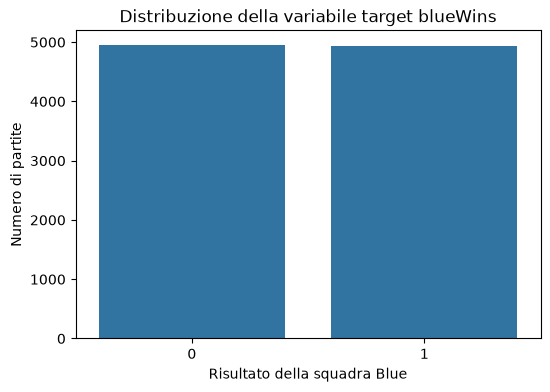

In [62]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="blueWins"
)

plt.title("Distribuzione della variabile target blueWins")
plt.xlabel("Risultato della squadra Blue")
plt.ylabel("Numero di partite")

plt.show()

### Interpretazione

La variabile target risulta sostanzialmente bilanciata.

Le vittorie e le sconfitte della squadra Blue rappresentano circa il 50% delle osservazioni ciascuna.

Non emerge quindi un problema significativo di class imbalance.

## 1.6 Distribuzione delle risorse

Viene analizzata la distribuzione del vantaggio in oro e in esperienza della squadra Blue rispetto alla squadra Red al minuto 10.

Un valore positivo di `blueGoldDiff` indica che Blue possiede più oro di Red, mentre un valore negativo indica uno svantaggio.

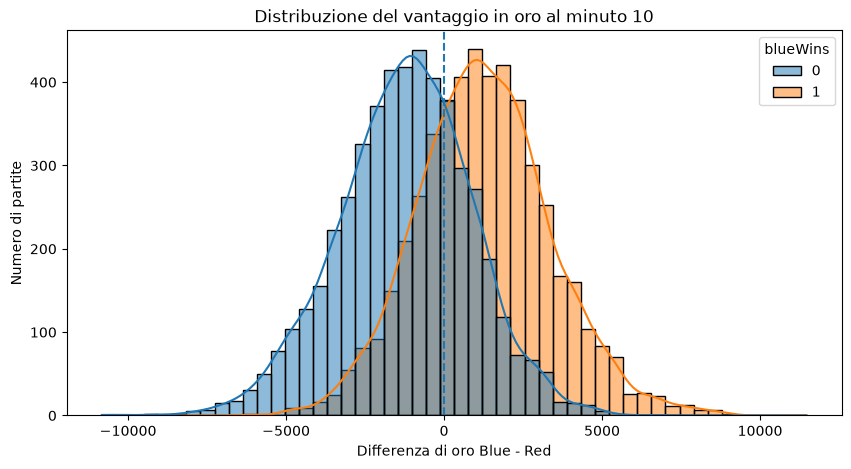

In [63]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="blueGoldDiff",
    hue="blueWins",
    bins=50,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.title("Distribuzione del vantaggio in oro al minuto 10")
plt.xlabel("Differenza di oro Blue - Red")
plt.ylabel("Numero di partite")

plt.show()

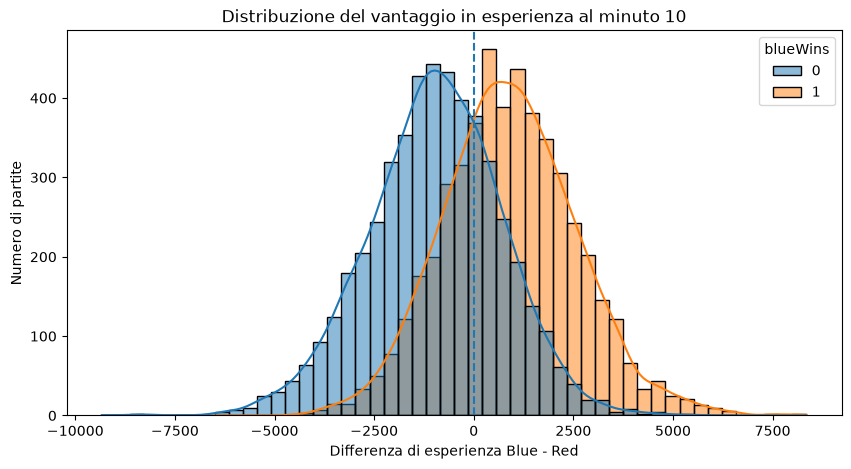

In [64]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="blueExperienceDiff",
    hue="blueWins",
    bins=50,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.title("Distribuzione del vantaggio in esperienza al minuto 10")
plt.xlabel("Differenza di esperienza Blue - Red")
plt.ylabel("Numero di partite")

plt.show()

## 1.7 Analisi degli outlier

I boxplot vengono utilizzati per identificare visivamente osservazioni molto distanti dalla parte centrale della distribuzione.

Questi valori vengono definiti potenziali outlier.

La presenza di un outlier non implica necessariamente che il dato sia errato: potrebbe rappresentare una partita rara ma reale.

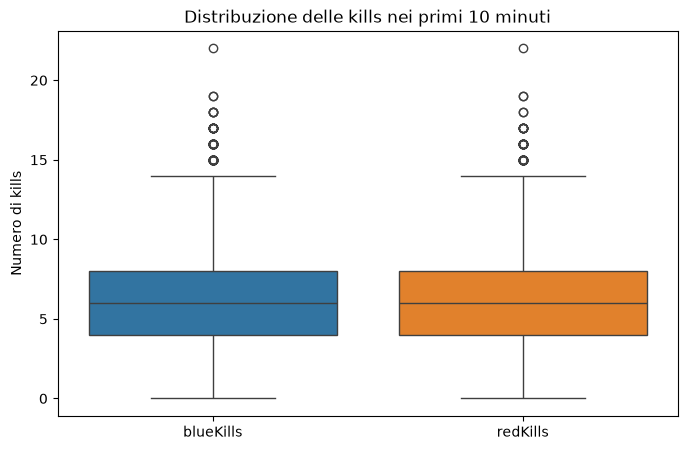

In [65]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df[["blueKills", "redKills"]]
)

plt.title("Distribuzione delle kills nei primi 10 minuti")
plt.ylabel("Numero di kills")

plt.show()

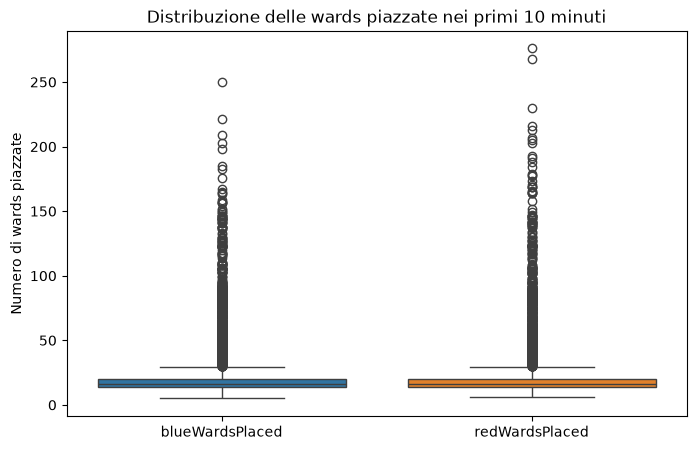

In [66]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df[["blueWardsPlaced", "redWardsPlaced"]]
)

plt.title("Distribuzione delle wards piazzate nei primi 10 minuti")
plt.ylabel("Numero di wards piazzate")

plt.show()

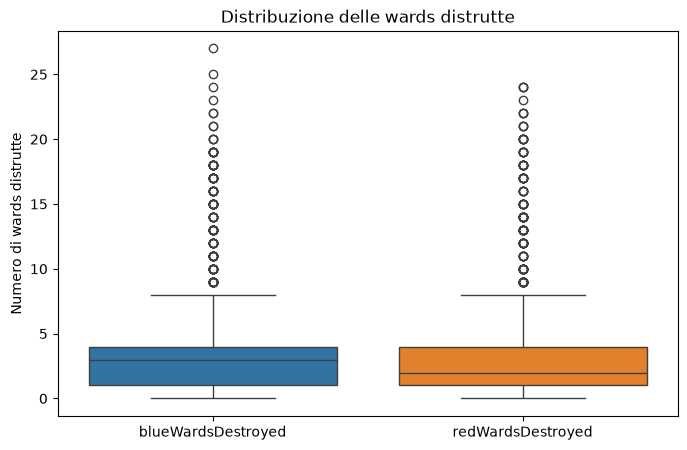

In [67]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df[[
        "blueWardsDestroyed",
        "redWardsDestroyed"
    ]]
)

plt.title("Distribuzione delle wards distrutte")
plt.ylabel("Numero di wards distrutte")

plt.show()

### Identificazione degli outlier tramite IQR

L'Interquartile Range (IQR) viene utilizzato per individuare statisticamente i valori estremi.

L'IQR è definito come:

IQR = Q3 - Q1

dove Q1 rappresenta il primo quartile e Q3 il terzo quartile.

Sono considerati potenziali outlier i valori inferiori a:

Q1 - 1.5 × IQR

o superiori a:

Q3 + 1.5 × IQR.

In [68]:
def get_outliers_iqr(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return lower_bound, upper_bound, outliers

In [69]:
outlier_columns = [
    "blueKills",
    "redKills",
    "blueWardsPlaced",
    "redWardsPlaced",
    "blueWardsDestroyed",
    "redWardsDestroyed"
]

for col in outlier_columns:

    lower, upper, outliers = get_outliers_iqr(df[col])

    print(
        f"{col}: "
        f"{len(outliers)} outlier "
        f"- intervallo [{lower:.2f}, {upper:.2f}]"
    )

blueKills: 88 outlier - intervallo [-2.00, 14.00]
redKills: 65 outlier - intervallo [-2.00, 14.00]
blueWardsPlaced: 1627 outlier - intervallo [5.00, 29.00]
redWardsPlaced: 1667 outlier - intervallo [5.00, 29.00]
blueWardsDestroyed: 136 outlier - intervallo [-3.50, 8.50]
redWardsDestroyed: 136 outlier - intervallo [-3.50, 8.50]


## Analisi delle relazioni tramite Scatterplot

Lo scatterplot permette di rappresentare graficamente la relazione tra due variabili quantitative.

Ogni punto del grafico rappresenta una partita. La posizione del punto è determinata dal valore assunto dalle due feature considerate.

Lo scatterplot consente di osservare visivamente la presenza di eventuali relazioni lineari, cluster o valori anomali prima di calcolare formalmente il coefficiente di correlazione di Pearson.

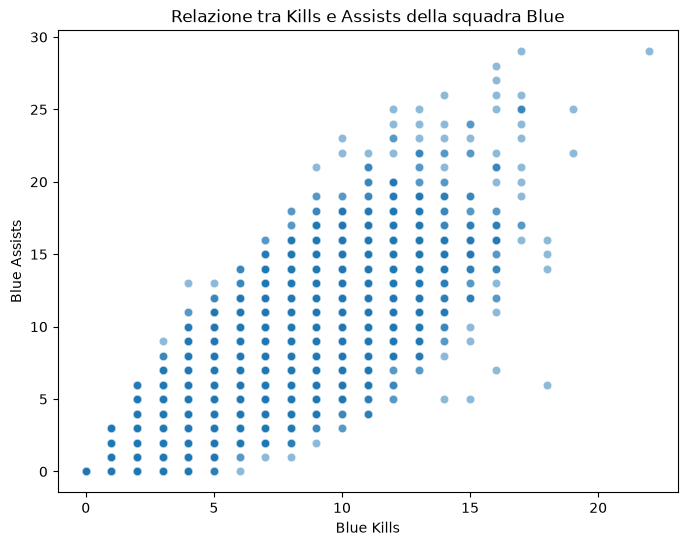

In [70]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="blueKills",
    y="blueAssists",
    alpha=0.5
)

plt.title("Relazione tra Kills e Assists della squadra Blue")
plt.xlabel("Blue Kills")
plt.ylabel("Blue Assists")

plt.show()

In [71]:
correlation_kills_assists = df["blueKills"].corr(df["blueAssists"])

print(
    "Correlazione Pearson tra blueKills e blueAssists:",
    round(correlation_kills_assists, 3)
)

Correlazione Pearson tra blueKills e blueAssists: 0.814


### Interpretazione: Kills e Assists

Lo scatterplot mostra una relazione positiva tra il numero di kills e il numero di assists della squadra Blue.

Il coefficiente di correlazione di Pearson è pari a circa 0.81, indicando una forte relazione lineare positiva tra le due variabili.

Questo risultato è coerente con le dinamiche di gioco, poiché una singola eliminazione può coinvolgere più giocatori della stessa squadra e generare quindi uno o più assists.

Nonostante la forte correlazione, kills e assists non rappresentano la stessa informazione e non sono matematicamente equivalenti.

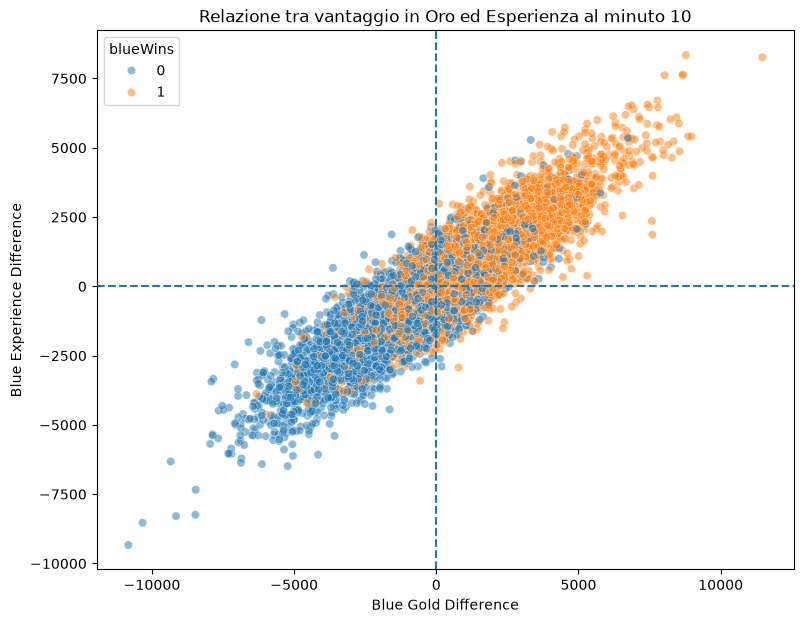

In [72]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=df,
    x="blueGoldDiff",
    y="blueExperienceDiff",
    hue="blueWins",
    alpha=0.5
)

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")

plt.title("Relazione tra vantaggio in Oro ed Esperienza al minuto 10")
plt.xlabel("Blue Gold Difference")
plt.ylabel("Blue Experience Difference")

plt.show()

In [73]:
correlation_gold_exp = df["blueGoldDiff"].corr(df["blueExperienceDiff"])

print(
    "Correlazione Pearson tra GoldDiff e ExperienceDiff:",
    round(correlation_gold_exp, 3)
)

Correlazione Pearson tra GoldDiff e ExperienceDiff: 0.895


### Interpretazione: Gold Difference ed Experience Difference

Lo scatterplot mostra una forte relazione positiva tra il vantaggio in oro e il vantaggio in esperienza della squadra Blue.

Il coefficiente di Pearson è pari a circa 0.895, indicando una forte relazione lineare positiva.

La colorazione dei punti tramite `blueWins` permette inoltre di osservare come le vittorie della squadra Blue tendano a concentrarsi maggiormente nelle zone del grafico in cui `blueGoldDiff` e `blueExperienceDiff` assumono valori positivi.

Questo suggerisce che un vantaggio economico e di esperienza nei primi 10 minuti sia associato a una maggiore probabilità di vittoria.

Le due variabili, tuttavia, non sono perfettamente equivalenti, poiché esistono partite in cui una squadra è avanti in oro ma non in esperienza, o viceversa.

## 1.8 Analisi di correlazione

Il coefficiente di correlazione di Pearson misura la forza della relazione lineare tra due variabili.

Il coefficiente assume valori compresi tra -1 e +1:

- valori vicini a +1 indicano una forte correlazione positiva;
- valori vicini a -1 indicano una forte correlazione negativa;
- valori vicini a 0 indicano assenza di una forte relazione lineare.

In [74]:
correlation_matrix = df_analysis.corr(method="pearson")

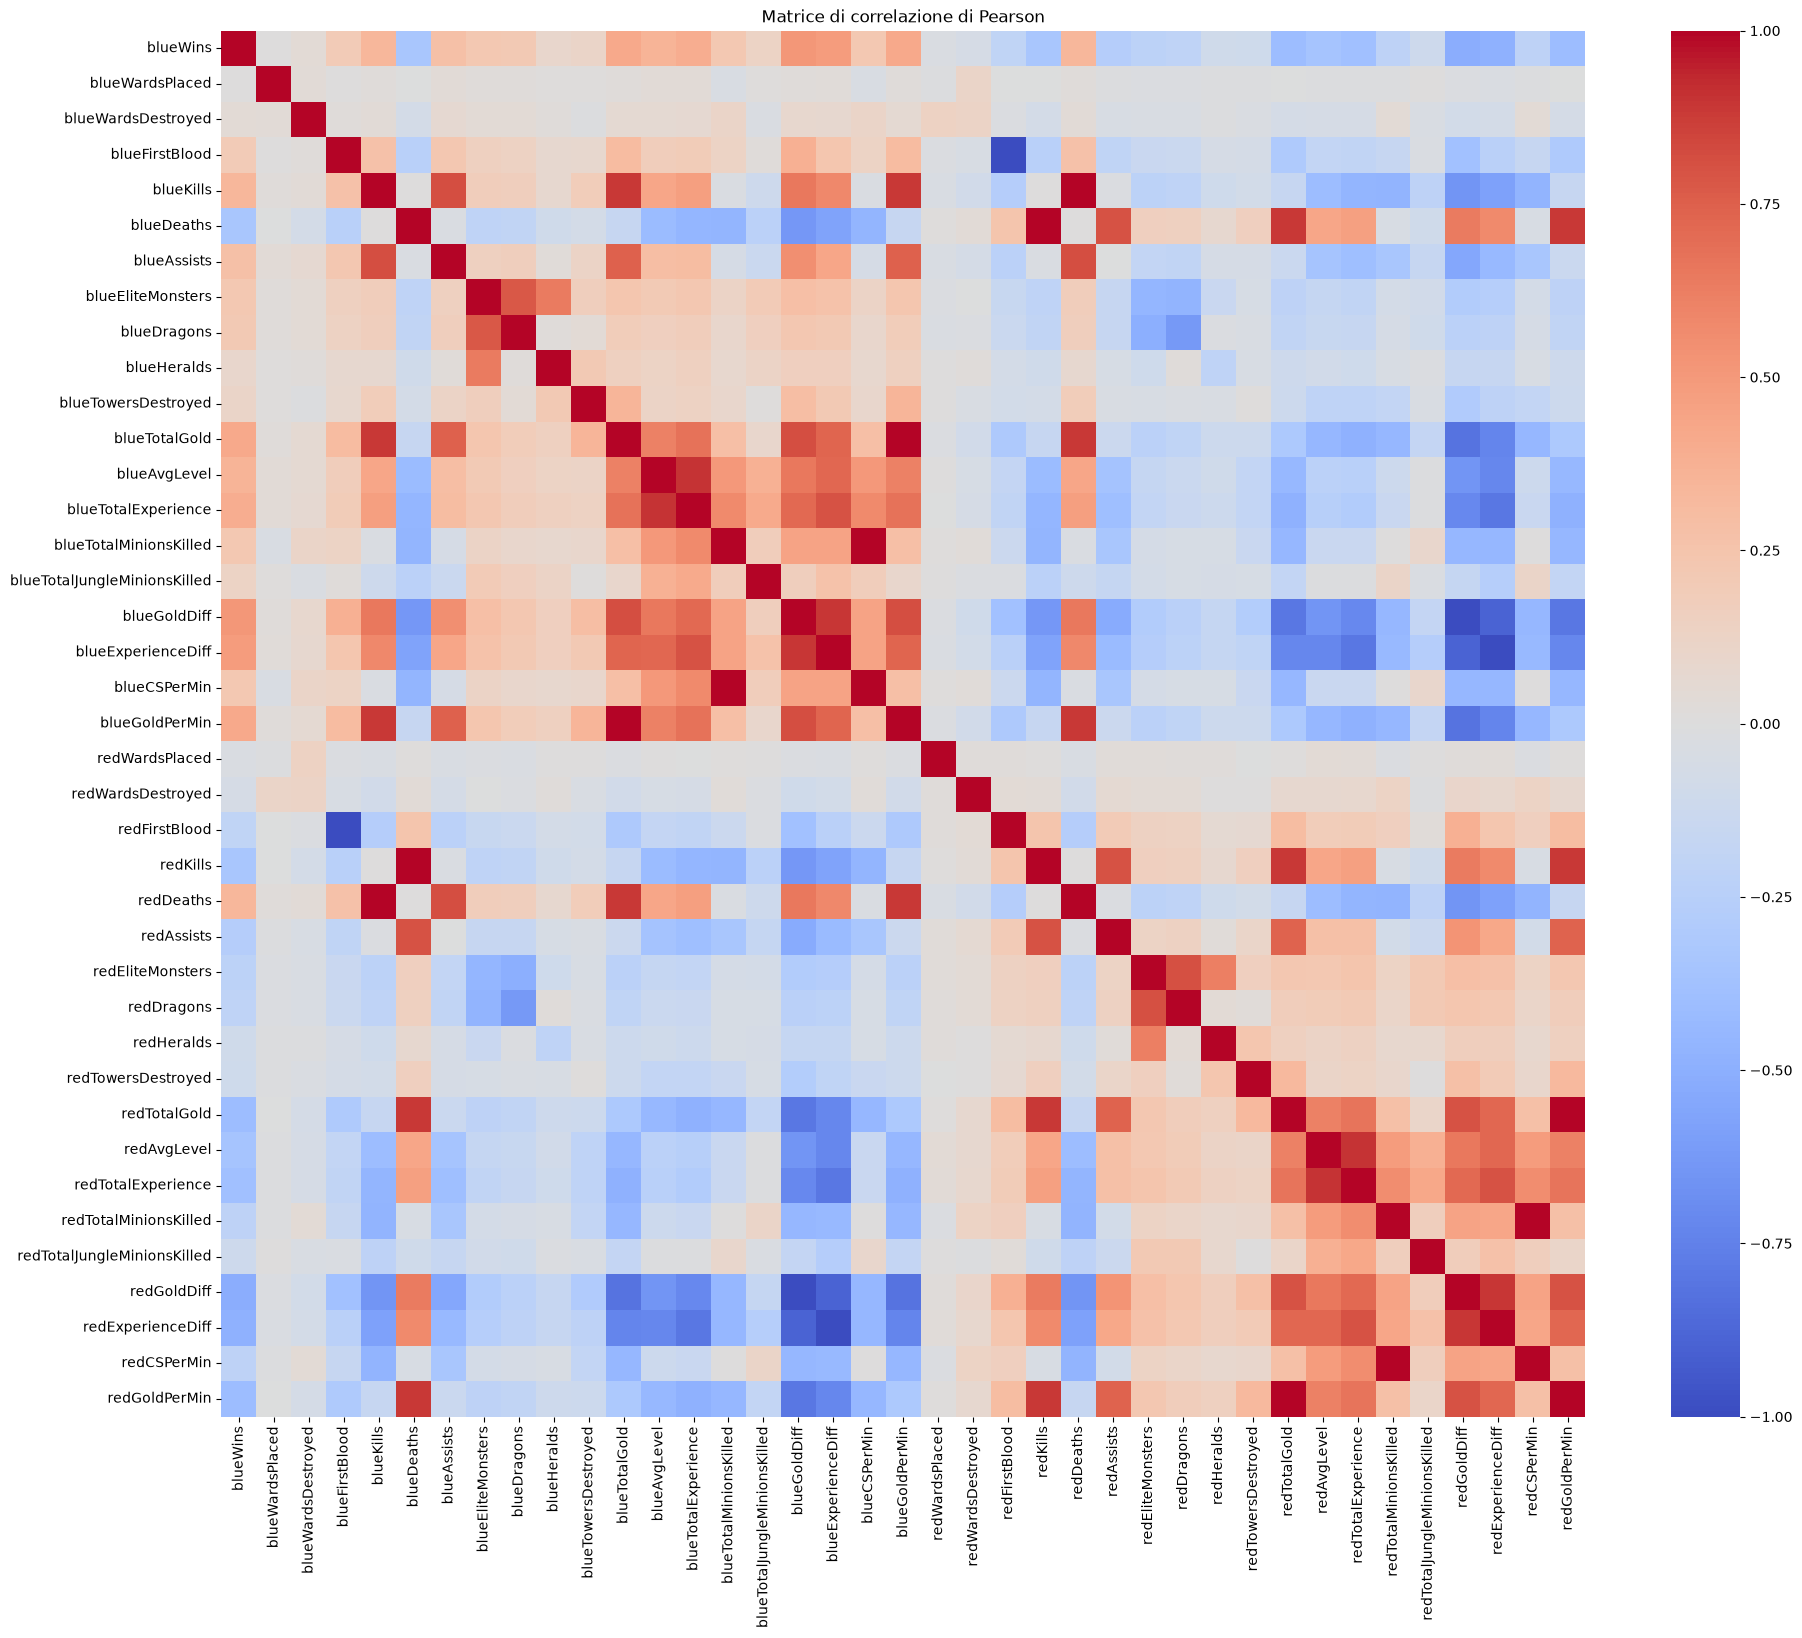

In [75]:
plt.figure(figsize=(22, 18))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Matrice di correlazione di Pearson")

plt.show()

### Correlazione delle feature con la vittoria

Viene analizzata separatamente la correlazione tra ogni feature e la variabile target `blueWins`.

Questo permette di individuare quali variabili presentano la relazione lineare più forte con l'esito finale della partita.

In [76]:
target_corr = (
    correlation_matrix["blueWins"]
    .drop("blueWins")
    .sort_values(key=abs, ascending=False)
)

target_corr

redGoldDiff                    -0.511119
blueGoldDiff                    0.511119
blueExperienceDiff              0.489558
redExperienceDiff              -0.489558
blueTotalGold                   0.417213
blueGoldPerMin                  0.417213
redTotalGold                   -0.411396
redGoldPerMin                  -0.411396
blueTotalExperience             0.396141
redTotalExperience             -0.387588
blueAvgLevel                    0.357820
redAvgLevel                    -0.352127
redKills                       -0.339297
blueDeaths                     -0.339297
blueKills                       0.337358
redDeaths                       0.337358
blueAssists                     0.276685
redAssists                     -0.271047
blueCSPerMin                    0.224909
blueTotalMinionsKilled          0.224909
blueEliteMonsters               0.221944
redEliteMonsters               -0.221551
blueDragons                     0.213768
redTotalMinionsKilled          -0.212171
redCSPerMin     

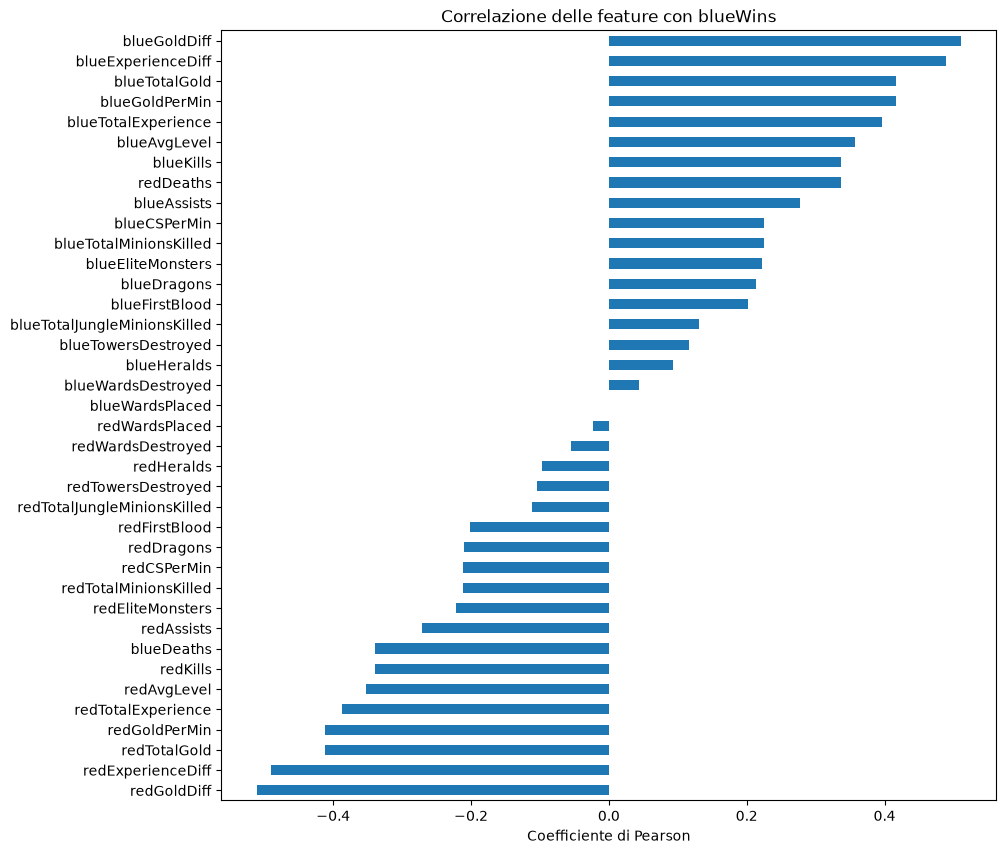

In [77]:
plt.figure(figsize=(10, 10))

target_corr.sort_values().plot(kind="barh")

plt.title("Correlazione delle feature con blueWins")
plt.xlabel("Coefficiente di Pearson")

plt.show()

## 1.9 Analisi della collinearità

La collinearità si verifica quando due o più feature contengono informazioni fortemente sovrapposte.

Una forte collinearità può creare ridondanza nel dataset e, per alcuni modelli, rendere più difficile interpretare il contributo delle singole variabili.

Vengono quindi individuate le coppie di feature con correlazione assoluta maggiore o uguale a 0.80.

In [78]:
feature_corr = (
    df_analysis
    .drop(columns=["blueWins"])
    .corr(method="pearson")
)

upper_triangle = feature_corr.where(
    np.triu(
        np.ones(feature_corr.shape),
        k=1
    ).astype(bool)
)

In [79]:
threshold = 0.80

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlazione"
]

high_corr_pairs["correlazione_assoluta"] = (
    high_corr_pairs["correlazione"].abs()
)

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["correlazione_assoluta"] >= threshold
]

high_corr_pairs = high_corr_pairs.sort_values(
    "correlazione_assoluta",
    ascending=False
)

high_corr_pairs

,feature_1,feature_2,correlazione,correlazione_assoluta
97,blueFirstBlood,redFirstBlood,-1.000000,1.000000
137,blueKills,redDeaths,1.000000,1.000000
174,blueDeaths,redKills,1.000000,1.000000
1139,redTotalGold,redGoldPerMin,1.000000,1.000000
643,blueExperienceDiff,redExperienceDiff,-1.000000,1.000000
604,blueGoldDiff,redGoldDiff,-1.000000,1.000000
511,blueTotalMinionsKilled,blueCSPerMin,1.000000,1.000000
398,blueTotalGold,blueGoldPerMin,1.000000,1.000000
1252,redTotalMinionsKilled,redCSPerMin,1.000000,1.000000
1171,redAvgLevel,redTotalExperience,0.901748,0.901748


## 1.10 Verifica delle dipendenze matematiche

Alcune variabili del dataset non sono semplicemente correlate, ma sono direttamente derivabili da altre variabili.

Queste dipendenze vengono verificate esplicitamente perché rappresentano una forma di ridondanza perfetta.

In [80]:
consistency_checks = {

    "First Blood complementare":
        (
            df["blueFirstBlood"] +
            df["redFirstBlood"] == 1
        ).all(),

    "Blue kills = Red deaths":
        (
            df["blueKills"] ==
            df["redDeaths"]
        ).all(),

    "Red kills = Blue deaths":
        (
            df["redKills"] ==
            df["blueDeaths"]
        ).all(),

    "Gold diff simmetrico":
        (
            df["blueGoldDiff"] ==
            -df["redGoldDiff"]
        ).all(),

    "Experience diff simmetrico":
        (
            df["blueExperienceDiff"] ==
            -df["redExperienceDiff"]
        ).all(),

    "Blue Gold/min derivato":
        np.allclose(
            df["blueGoldPerMin"],
            df["blueTotalGold"] / 10
        ),

    "Red Gold/min derivato":
        np.allclose(
            df["redGoldPerMin"],
            df["redTotalGold"] / 10
        ),

    "Blue CS/min derivato":
        np.allclose(
            df["blueCSPerMin"],
            df["blueTotalMinionsKilled"] / 10
        ),

    "Red CS/min derivato":
        np.allclose(
            df["redCSPerMin"],
            df["redTotalMinionsKilled"] / 10
        ),

    "Blue Elite Monsters":
        (
            df["blueEliteMonsters"] ==
            df["blueDragons"] +
            df["blueHeralds"]
        ).all(),

    "Red Elite Monsters":
        (
            df["redEliteMonsters"] ==
            df["redDragons"] +
            df["redHeralds"]
        ).all()
}

pd.Series(consistency_checks)

First Blood complementare     True
Blue kills = Red deaths       True
Red kills = Blue deaths       True
Gold diff simmetrico          True
Experience diff simmetrico    True
Blue Gold/min derivato        True
Red Gold/min derivato         True
Blue CS/min derivato          True
Red CS/min derivato           True
Blue Elite Monsters           True
Red Elite Monsters            True
dtype: bool

## 1.11 Conclusioni

L'analisi esplorativa ha permesso di verificare la qualità e la struttura del dataset.

Il dataset non presenta valori mancanti o righe duplicate e la variabile target `blueWins` risulta sostanzialmente bilanciata tra vittorie e sconfitte della squadra Blue.

L'analisi delle distribuzioni permette di osservare il comportamento delle principali variabili di gioco e di individuare la presenza di valori estremi, in particolare nelle variabili relative alle wards.

La matrice di correlazione evidenzia inoltre relazioni significative tra diverse feature. In particolare, alcune variabili risultano perfettamente o quasi perfettamente collineari perché contengono informazioni equivalenti o direttamente derivabili da altre variabili.

Tra gli esempi principali si osservano:

- `blueTotalGold` e `blueGoldPerMin`;
- `blueTotalMinionsKilled` e `blueCSPerMin`;
- `blueKills` e `redDeaths`;
- `blueGoldDiff` e `redGoldDiff`;
- `blueExperienceDiff` e `redExperienceDiff`;
- `blueFirstBlood` e `redFirstBlood`;
- `EliteMonsters`, che è ottenuta dalla somma di Dragons e Heralds.

Queste ridondanze verranno considerate nella successiva fase di preprocessing e feature engineering, durante la quale verranno selezionate le variabili da utilizzare per l'addestramento dei modelli predittivi.